# analysis_b / 03 — Latent Topic Discovery (LDA)

Unsupervised discovery of latent thematic structure in the corpus. No pre-imposed categories — topics are described purely from what emerges.

**Pipeline:** DTM → K selection (perplexity + PMI coherence) → fit final LDA → topic profiling (top words + top documents) → score/flair correlations

**Reads:** `artifacts/posts_clean.parquet`  
**Writes:** `artifacts/theta.npy`, `artifacts/phi.npy`, `artifacts/lda_vocab.json`, `artifacts/lda_model.pkl`, `artifacts/topic_labels.json`

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import textwrap
import warnings
import joblib
from pathlib import Path
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import train_test_split
from scipy.sparse import csc_matrix
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

ARTIFACTS = Path('artifacts')

df = pd.read_parquet(ARTIFACTS / 'posts_clean.parquet')
print(f'Posts: {len(df):,}')
df[['text_lemma', 'score', 'year_month', 'day_idx']].head(3)

Posts: 63,305


,text_lemma,score,year_month,day_idx
0,sit outside deck hear scream second sound girl...,1,2025-05,138
1,cougar bobcat remember sound woman scream,2,2025-05,138
2,fox fox live start scream evening night sound ...,4,2025-05,138


## 1. Document-Term Matrix

In [4]:
vec = CountVectorizer(min_df=10, max_df=0.90)
dtm = vec.fit_transform(df['text_lemma'])
vocab = vec.get_feature_names_out()

print(f'DTM      : {dtm.shape[0]:,} docs × {dtm.shape[1]:,} terms')
print(f'Sparsity : {1 - dtm.nnz / (dtm.shape[0] * dtm.shape[1]):.2%}')

X_train, X_test = train_test_split(dtm, test_size=0.10, random_state=42)
print(f'Train: {X_train.shape[0]:,}   Test: {X_test.shape[0]:,}')

DTM      : 63,305 docs × 7,864 terms
Sparsity : 99.68%
Train: 56,974   Test: 6,331


## 2. K Selection

- **Perplexity** on held-out 10% — lower is better; tends to keep decreasing, so not sufficient alone
- **PMI coherence** — higher means more semantically coherent topics; choose K at the elbow

In [5]:
dtm_csc = csc_matrix((dtm > 0).astype(np.float32))

def pmi_coherence(topic_idx, phi, dtm_csc, n_top=10):
    top_w = phi[topic_idx].argsort()[::-1][:n_top]
    cols  = [
        np.asarray(dtm_csc.getcol(int(w)).todense()).flatten() > 0
        for w in top_w
    ]
    pmis = []
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            p_i  = cols[i].mean()
            p_j  = cols[j].mean()
            p_ij = (cols[i] & cols[j]).mean()
            if p_i > 0 and p_j > 0 and p_ij > 0:
                pmis.append(np.log(p_ij / (p_i * p_j)))
    return float(np.mean(pmis)) if pmis else 0.0

In [31]:
K_RANGE = [1,2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

for K in K_RANGE:
    lda_k = LatentDirichletAllocation(
        n_components=K, learning_method='online', max_iter=20, random_state=42
    )
    lda_k.fit(X_train)
    perp  = lda_k.perplexity(X_test)
    phi_k = lda_k.components_ / lda_k.components_.sum(axis=1, keepdims=True)
    coh   = float(np.mean([pmi_coherence(k, phi_k, dtm_csc) for k in range(K)]))
    results.append({'K': K, 'perplexity': perp, 'coherence': coh})
    print(f'K={K:2d}  perplexity={perp:9.1f}  coherence={coh:.4f}')

results_df = pd.DataFrame(results)

K= 1  perplexity=   1595.2  coherence=0.5734
K= 2  perplexity=   1584.3  coherence=0.6822
K= 3  perplexity=   1658.4  coherence=0.7953
K= 4  perplexity=   1721.5  coherence=0.8016
K= 5  perplexity=   1811.0  coherence=0.8032
K= 6  perplexity=   1894.8  coherence=0.8252
K= 7  perplexity=   1946.0  coherence=0.7952
K= 8  perplexity=   1992.2  coherence=0.8079
K= 9  perplexity=   2054.5  coherence=0.8427
K=10  perplexity=   2111.0  coherence=0.7988


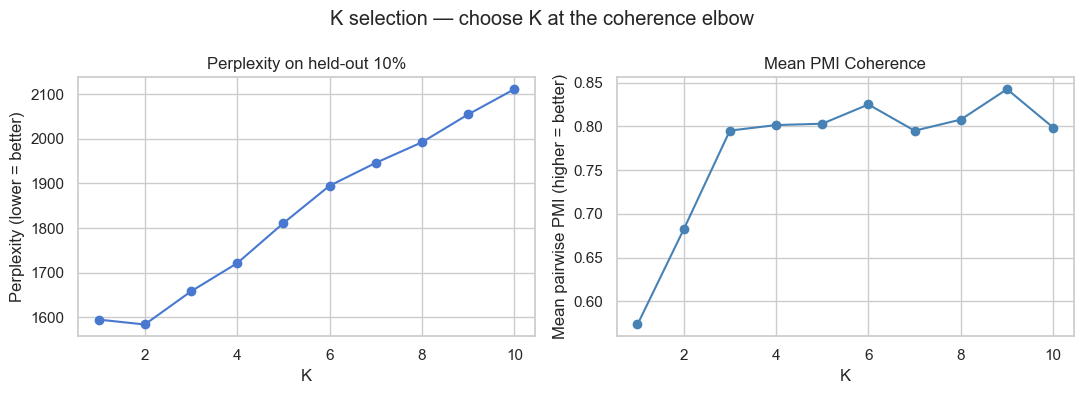

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(results_df['K'], results_df['perplexity'], marker='o')
ax1.set_title('Perplexity on held-out 10%')
ax1.set_xlabel('K')
ax1.set_ylabel('Perplexity (lower = better)')

ax2.plot(results_df['K'], results_df['coherence'], marker='o', color='steelblue')
ax2.set_title('Mean PMI Coherence')
ax2.set_xlabel('K')
ax2.set_ylabel('Mean pairwise PMI (higher = better)')

plt.suptitle('K selection — choose K at the coherence elbow')
plt.tight_layout()
plt.show()

## 3. Fit Final Model

Set `K_FINAL` based on the plot above.

In [6]:
K_FINAL = 4

lda = LatentDirichletAllocation(
    n_components=K_FINAL, learning_method='batch', max_iter=100, random_state=42
)
lda.fit(dtm)

print(f'Final model: K={K_FINAL}, held-out perplexity={lda.perplexity(X_test):.1f}')

Final model: K=4, held-out perplexity=1704.8


In [7]:
# phi   : (K, V) normalized topic-word matrix
# theta : (N, K) document-topic distribution
phi   = lda.components_ / lda.components_.sum(axis=1, keepdims=True)
theta = lda.transform(dtm)

print(f'phi   shape : {phi.shape}')
print(f'theta shape : {theta.shape}')
print(f'theta row-sum check (should be ~1.0): {theta.sum(axis=1).mean():.4f}')

phi   shape : (4, 7864)
theta shape : (63305, 4)
theta row-sum check (should be ~1.0): 1.0000


## 4. Topic Profiling

For each topic: top words + top 5 documents by theta loading. Read the documents — do not rely on words alone. Fill in the annotation table below.

In [8]:
N_TOP_WORDS = 20
vocab_list  = list(vocab)

print('Top words per topic')
print('=' * 70)
for k in range(K_FINAL):
    top_idx   = phi[k].argsort()[::-1][:N_TOP_WORDS]
    top_words = ', '.join(vocab_list[i] for i in top_idx)
    print(f'Topic {k:2d}: {top_words}')

Top words per topic
Topic  0: house, hear, room, say, time, tell, year, door, get, come, day, old, home, happen, know, mom, think, night, live, friend
Topic  1: see, feel, sleep, look, dream, night, time, wake, eye, happen, bed, light, thing, think, room, face, experience, black, know, head
Topic  2: know, spirit, thing, people, feel, help, life, good, think, believe, want, energy, try, need, demon, way, entity, bad, time, love
Topic  3: people, paranormal, experience, think, thing, know, ghost, story, believe, post, happen, time, real, find, hear, sound, video, see, read, look


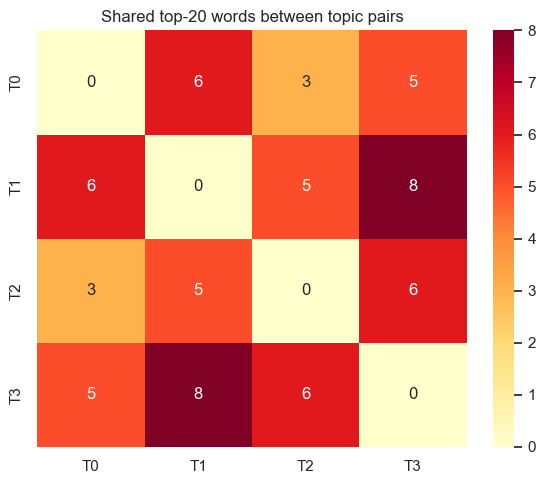


Shared words (top-20) per pair:
  T0 ∩ T1 (6): happen, know, night, room, think, time
  T0 ∩ T2 (3): know, think, time
  T0 ∩ T3 (5): happen, hear, know, think, time
  T1 ∩ T2 (5): feel, know, thing, think, time
  T1 ∩ T3 (8): experience, happen, know, look, see, thing, think, time
  T2 ∩ T3 (6): believe, know, people, thing, think, time


In [9]:
import itertools

N_TOP = 20  # top words per topic to compare

# Get top-N word sets per topic
top_word_sets = {}
for k in range(K_FINAL):
    top_idx = phi[k].argsort()[::-1][:N_TOP]
    top_word_sets[k] = set(vocab_list[i] for i in top_idx)

# Pairwise overlap matrix
overlap = np.zeros((K_FINAL, K_FINAL), dtype=int)
for i, j in itertools.combinations(range(K_FINAL), 2):
    shared = top_word_sets[i] & top_word_sets[j]
    overlap[i, j] = len(shared)
    overlap[j, i] = len(shared)

# Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    overlap, annot=True, fmt='d', cmap='YlOrRd',
    xticklabels=[f'T{k}' for k in range(K_FINAL)],
    yticklabels=[f'T{k}' for k in range(K_FINAL)],
    ax=ax
)
ax.set_title(f'Shared top-{N_TOP} words between topic pairs')
plt.tight_layout()
plt.show()

# Print which words are shared per pair
print(f'\nShared words (top-{N_TOP}) per pair:')
for i, j in itertools.combinations(range(K_FINAL), 2):
    shared = sorted(top_word_sets[i] & top_word_sets[j])
    print(f'  T{i} ∩ T{j} ({len(shared)}): {", ".join(shared) if shared else "none"}')


### FREX — Frequency × Exclusivity

Top words by raw probability alone are dominated by corpus-wide filler (*think*, *see*, *people*).
FREX re-ranks words by the harmonic mean of two ECDF-normalised scores:

- **Frequency** `phi[k, w]` — probability of the word within the topic  
- **Exclusivity** `phi[k, w] / Σ_k phi[k, w]` — share of the word's total mass in this topic

A word scores high only when it is *both* common in the topic *and* concentrated there.
`w` (default 0.5) trades off the two components.


In [49]:
from scipy.stats import rankdata

vocab_list = list(vocab) 

def frex(phi, w=0.5, n_top=15):
    """
    phi   : (K, V) row-normalised topic-word matrix
    w     : weight on frequency (1-w goes to exclusivity)
    returns frex_scores (K, V) and top word indices (K, n_top)
    """
    K, V = phi.shape

    # Exclusivity: fraction of word's total mass in each topic
    col_sums = phi.sum(axis=0)                          # (V,)
    excl = phi / np.where(col_sums > 0, col_sums, 1)   # (K, V)

    # ECDF-normalise within each topic (rank / V)
    freq_ecdf = np.apply_along_axis(
        lambda row: rankdata(row) / V, axis=1, arr=phi
    )
    excl_ecdf = np.apply_along_axis(
        lambda row: rankdata(row) / V, axis=1, arr=excl
    )

    # Harmonic mean of the two ECDF scores
    scores = 1.0 / (w / freq_ecdf + (1 - w) / excl_ecdf)

    top_idx = scores.argsort(axis=1)[:, ::-1][:, :n_top]
    return scores, top_idx


N_FREX   = 15
FREX_W   = 0.5   # 0.5 = balanced; closer to 1 = favour frequency

frex_scores, frex_top = frex(phi, w=FREX_W, n_top=N_FREX)

print(f'FREX top-{N_FREX} words per topic  (w={FREX_W})')
print('=' * 70)
for k in range(K_FINAL):
    words = ', '.join(vocab_list[i] for i in frex_top[k])
    print(f'Topic {k}: {words}')



FREX top-15 words per topic  (w=0.5)
Topic 0: mom, house, dad, brother, sister, knock, kitchen, school, grandma, grandmother, basement, upstairs, neighbor, cousin, town
Topic 1: sleep, eye, black, asleep, paralysis, awake, tall, red, leg, mirror, bright, arm, float, blue, skin
Topic 2: spiritual, soul, negative, mental, angel, psychic, ability, prayer, sage, religion, health, communicate, protection, guide, practice
Topic 3: evidence, theory, prove, record, sub, science, fake, proof, phenomenon, link, app, audio, scientific, investigation, capture


In [50]:
# --- side-by-side comparison: raw top-10 vs FREX top-10 ---
N_CMP = 10
cols = pd.MultiIndex.from_product(
    [[f'Topic {k}' for k in range(K_FINAL)], ['Raw', 'FREX']]
)
data = {}
for k in range(K_FINAL):
    raw_words  = [vocab_list[i] for i in phi[k].argsort()[::-1][:N_CMP]]
    frex_words = [vocab_list[i] for i in frex_top[k][:N_CMP]]
    data[(f'Topic {k}', 'Raw')]  = raw_words
    data[(f'Topic {k}', 'FREX')] = frex_words

cmp_df = pd.DataFrame(data, index=range(1, N_CMP + 1))
cmp_df.index.name = 'Rank'
cmp_df



Topic 0              Topic 1             Topic 2                Topic 3  \
         Raw         FREX     Raw       FREX      Raw       FREX         Raw   
Rank                                                                           
1      house          mom     see      sleep     know  spiritual      people   
2       hear        house    feel        eye   spirit       soul  paranormal   
3       room          dad   sleep      black    thing   negative  experience   
4        say      brother    look     asleep   people     mental       think   
5       time       sister   dream  paralysis     feel      angel       thing   
6       tell        knock   night      awake     help    psychic        know   
7       year      kitchen    time       tall     life    ability       ghost   
8       door       school    wake        red     good     prayer       story   
9        get      grandma     eye        leg    think       sage     believe   
10      come  grandmother  happen     mirror  believe   religion        post   

                  
            FREX  
Rank              
1       evidence  
2         theory  
3          prove  
4         record  
5            sub  
6        science  
7           fake  
8          proof  
9     phenomenon  
10          link

### Doc inspection

In [10]:
N_TOP_DOCS = 10

for k in range(K_FINAL):
    print('=' * 70)
    print(f'TOPIC {k} — top {N_TOP_DOCS} documents')
    print('=' * 70)
    top_doc_idx = theta[:, k].argsort()[::-1][:N_TOP_DOCS]
    for rank, idx in enumerate(top_doc_idx, start=1):
        row     = df.iloc[idx]
        loading = theta[idx, k]
        snippet = row['text_clean']
        date    = str(row.get('date', row.get('year_month', '')))
        print(f'  [{rank}] theta={loading:.3f} | {date}')
        print(textwrap.fill(snippet, width=76, initial_indent='      ', subsequent_indent='      '))
        print()
    print()

TOPIC 0 — top 10 documents
  [1] theta=0.995 | 2025-05-16 00:00:00
      Our farm has 7.5 acres. We have goats, chickens, turkeys, dogs, and
      cats(we had cows at the time of this as well). My aunts family lives
      on our land with us and we all do stuff around the farm. Milking,
      gathering eggs, feeding animals, ect. About a year ago, my aunt was
      walking through our pasture out to the chicken pen we had set up to
      shut them in for the night. We had a few goats in an electric fence by
      the front of our property. As she was walking back to her house she
      heard a female voice saying "hi goats hi goats! Goaty goaty goaties"
      in a kind of high pitched way. Nobody was outside but her. Super
      weird. My brother was feeding our dogs when he heard a female voice
      saying "here chickie chickie chickies" to the baby chicks that were at
      the front of our property(same spot as the goats were a week prior).
      Again, super weird. My cousin was o

In [11]:
N_TOP_DOCS = 10
md_path    = ARTIFACTS / 'top_docs.md'

lines = []
for k in range(K_FINAL):
    lines.append(f'# TOPIC {k} — top {N_TOP_DOCS} documents\n\n')
    top_doc_idx = theta[:, k].argsort()[::-1][:N_TOP_DOCS]
    for rank, idx in enumerate(top_doc_idx, start=1):
        row     = df.iloc[idx]
        loading = theta[idx, k]
        snippet = str(row['text_clean'])
        date    = str(row.get('date', row.get('year_month', '')))
        lines.append(f'- [{rank}] theta={loading:.3f} | {date}\n\n')
        wrapped = textwrap.fill(snippet, width=76,
                                initial_indent='  ',
                                subsequent_indent='  ')
        lines.append(f'{wrapped}\n\n')
    lines.append('\n---\n\n')

md_path.write_text(''.join(lines), encoding='utf-8')
print(f'Written → {md_path}')


Written → artifacts\top_docs.md


Topic 0: associated with health and mental health


In [27]:
N_SAMPLE    = 5
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

W = 82  # paragraph wrap width

dominant   = theta.argmax(axis=1)
is_post    = (df['type'] == 'post').values

for k in range(K_FINAL):
    print('\n' + '─' * W)
    print(f'  TOPIC {k} — {N_SAMPLE} sampled posts (dominant-member only)')
    print('─' * W)

    members    = np.where((dominant == k) & is_post)[0]
    sample_idx = rng.choice(members, size=min(N_SAMPLE, len(members)), replace=False)

    for rank, idx in enumerate(sample_idx, start=1):
        row     = df.iloc[idx]
        loading = theta[idx, k]
        date    = str(row.get('date', row.get('year_month', '')))

        print(f'\n  [{rank}]  {date}  |  score={row["score"]}  |  theta={loading:.3f}')
        print('  ' + '─' * (W - 2))

        paragraph = textwrap.fill(str(row['text_clean']), width=W - 4,
                                  initial_indent='  ',
                                  subsequent_indent='  ')
        print(paragraph)
        print()



──────────────────────────────────────────────────────────────────────────────────
  TOPIC 0 — 5 sampled posts (dominant-member only)
──────────────────────────────────────────────────────────────────────────────────

  [1]  2025-01-29 00:00:00  |  score=1  |  theta=0.568
  ────────────────────────────────────────────────────────────────────────────────
  So this happened about 4 years ago or so. I was dating a man who was an
  extreme skeptic when I have always been 100% a believer, even with only one
  personal paranormal experience before. Which is a cool story for another
  time. He and I had been dating for about 3 years at this point, and I have
  always had a rule about no pranking, scaring, or tricking my partner and
  have always been completely honest with him, and he had the same values with
  me. Despite him being a non-believer, to this day, he


  [2]  2025-03-13 00:00:00  |  score=1  |  theta=0.414
  ──────────────────────────────────────────────────────────────────────

## 5. Topic Distribution Heatmap

Mean theta per topic across the full corpus — shows which topics dominate overall.

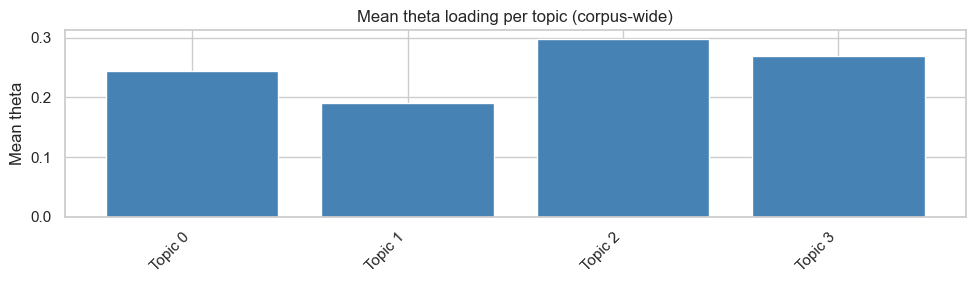

In [54]:
mean_theta = theta.mean(axis=0)
topic_labels_tmp = [f'Topic {k}' for k in range(K_FINAL)]

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(K_FINAL), mean_theta, color='steelblue')
ax.set_xticks(range(K_FINAL))
ax.set_xticklabels(topic_labels_tmp, rotation=45, ha='right')
ax.set_title('Mean theta loading per topic (corpus-wide)')
ax.set_ylabel('Mean theta')
plt.tight_layout()
plt.show()

## 6. Score Correlation

Spearman rho between post score and each topic's theta loading. Reveals whether any topics attract more engagement. Bonferroni-corrected.

In [55]:
score_vals  = df['score'].fillna(0).values
alpha_bonf  = 0.05 / K_FINAL

print('Spearman rho: score ~ topic theta loading')
print(f'(* = Bonferroni-significant, threshold p < {alpha_bonf:.4f})')
print()
for k in range(K_FINAL):
    rho, p = spearmanr(score_vals, theta[:, k])
    sig    = '*' if p < alpha_bonf else ''
    print(f'  Topic {k:2d}: rho={rho:+.3f}  p={p:.4f}  {sig}')

Spearman rho: score ~ topic theta loading
(* = Bonferroni-significant, threshold p < 0.0125)

  Topic  0: rho=+0.086  p=0.0000  *
  Topic  1: rho=-0.001  p=0.7418  
  Topic  2: rho=-0.060  p=0.0000  *
  Topic  3: rho=-0.043  p=0.0000  *


## 7. Write Artifacts

In [56]:
np.save(ARTIFACTS / 'theta.npy', theta)
np.save(ARTIFACTS / 'phi.npy',   phi)

with open(ARTIFACTS / 'lda_vocab.json', 'w') as fh:
    json.dump(list(vocab), fh)

joblib.dump(lda, ARTIFACTS / 'lda_model.pkl')

# Fill in labels before running 04_temporal.ipynb
template = {str(k): f'Topic {k} — label here' for k in range(K_FINAL)}
with open(ARTIFACTS / 'topic_labels.json', 'w') as fh:
    json.dump(template, fh, indent=2)

print('Artifacts written:')
for name in ('theta.npy', 'phi.npy', 'lda_vocab.json', 'lda_model.pkl', 'topic_labels.json'):
    p = ARTIFACTS / name
    if p.exists():
        print(f'  {p}  ({p.stat().st_size / 1024:.1f} KB)')

print()
print('Next: fill in topic_labels.json, then run 04_temporal.ipynb.')

Artifacts written:
  artifacts\theta.npy  (1978.4 KB)
  artifacts\phi.npy  (245.9 KB)
  artifacts\lda_vocab.json  (83.8 KB)
  artifacts\lda_model.pkl  (497.7 KB)
  artifacts\topic_labels.json  (0.1 KB)

Next: fill in topic_labels.json, then run 04_temporal.ipynb.


## Things worth knowing
